Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Constants and Global variables

In [2]:
# Constants
EXPRESSION_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_KO\\Expression_TE_DESeq_KO.csv"
DEA_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_KO\\DEA_TE_DESeq_KO.csv"
CLINICAL_DATA = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\SraRunTable_Liu24.csv"
INTERGENIC_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\TE_Intergenic_With_Distances.bed"


# Variables
expression_df = None
dea_df = None
genes_of_interest = None

Expression - Import

In [3]:
expression_df = pd.read_csv(EXPRESSION_FILE)
expression_df.rename(columns = {'Unnamed: 0' : 'TE'}, inplace = True)
expression_df.head()

,TE,GSM7232994,GSM7232993,GSM7232992,GSM7232991,GSM7232990,GSM7232989,GSM7232988,GSM7232987,GSM7232986,GSM7232985,GSM7232984,GSM7232983
0,TE_L2a_dup1,0,0,13,4,0,0,1,0,0,0,0,0
1,TE_L3_dup1,9,2,0,0,0,2,0,4,0,0,0,0
2,TE_MLT1K_dup1,0,0,0,0,0,2,0,0,0,5,6,0
3,TE_L2a_dup3,3,0,5,0,1,0,0,0,1,0,1,0
4,TE_L1PA14_dup1,0,0,0,0,0,10,2,2,0,0,6,0


DEA - Import

In [4]:
dea_df = pd.read_csv(DEA_FILE)
dea_df.rename(columns = {'Unnamed: 0' : 'TE'}, inplace = True)
dea_df.dropna(subset =['padj'], inplace = True)
dea_df.head()

,TE,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,TE_MER58A_dup10177,296.136900,5.300295,0.434757,12.191396,3.454517e-34,6.927965e-29
1,TE_L2a_dup73868,245.715392,4.725447,0.419721,11.258533,2.102290e-29,2.108050e-24
2,TE_HERVH-int_dup1414,348.370041,5.398390,0.497512,10.850770,1.977520e-27,1.321959e-22
3,TE_MIR3_dup5877,170.578610,5.207047,0.494716,10.525332,6.602853e-26,3.310472e-21
4,TE_HERVH-int_dup1411,149.311879,5.701412,0.553048,10.309070,6.411857e-25,2.571770e-20


Volcano plot

Classification
Non-significant    191562
Up-regulated         8305
Down-regulated        681
Name: count, dtype: int64
8986
Total tes:
1209386
379704
          0         1         2                  TE      4  5    6     7  \
0      chr1     78890     79850     TE_L1PREC2_dup1   5656  +   L1  LINE   
1      chr1     81693     82270        TE_L1M5_dup5    435  +   L1  LINE   
2      chr1     88143     88823          TE_L2_dup3    811  +   L2  LINE   
3      chr1    883243    885344       TE_L1PA7_dup8  11284  -   L1  LINE   
4      chr1    885340    887183       TE_L1PA7_dup9   7271  -   L1  LINE   
...     ...       ...       ...                 ...    ... ..  ...   ...   
61955  chrY  56859952  56860360   TE_L1MEd_dup22133    424  +   L1  LINE   
61956  chrY  56862621  56862906  TE_AluJb_dup131763   1921  -  Alu  SINE   
61957  chrY  56875907  56876009   TE_L1MEg_dup15207    242  +   L1  LINE   
61958  chrY  56876011  56876348   TE_AluJr_dup88524   1452  +  Alu  SINE   
61959  chrY  5

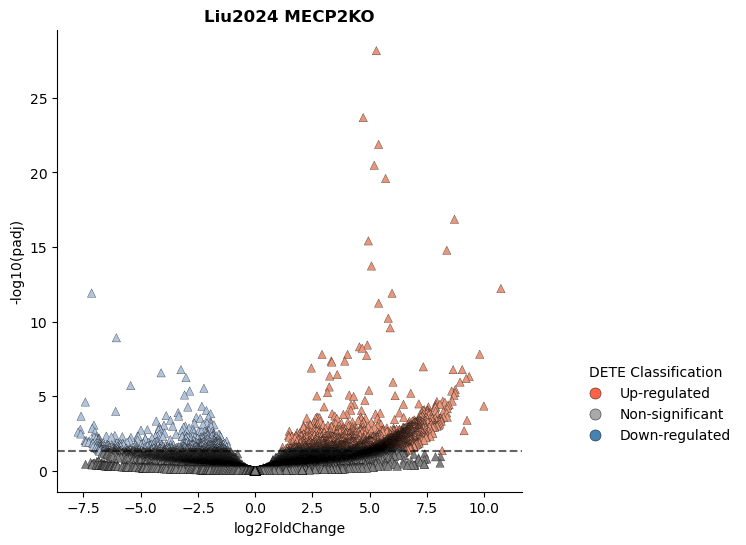

In [5]:

# Organizes the classification, according to the defined values
def organize_classification():
    dea_df['-log10(padj)'] = -np.log10(dea_df['padj'])

    dea_df['Classification'] = dea_df.apply(
        lambda row:
        'Up-regulated' if (row['log2FoldChange'] > 0 and row['padj'] < 0.05)
        else 'Down-regulated' if (row['log2FoldChange'] < -0 and row['padj'] < 0.05)
        else 'Non-significant',
        axis = 1
    )

# Sets the graph's reference lines and labels
def set_lines_and_labels(ax):
    ax.axhline(y = -np.log10(0.05), color = 'black', linestyle = '--', alpha = 0.6)

    ax.set_title('Liu2024 MECP2KO', fontweight = 'bold', fontsize = 12)
    ax.set_xlabel('log2FoldChange')
    ax.set_ylabel('-log10(padj)')

# Gets the genes with the biggest change in expression
def get_genes_of_interest():
    significant_df = dea_df[dea_df['Classification'] != 'Non-significant']
    top_up = significant_df.nlargest(5, 'log2FoldChange')['TE'].tolist()
    top_down = significant_df.nsmallest(5, 'log2FoldChange')['TE'].tolist()
    genes_of_interest = top_up + top_down

    dea_df['Classification'] = np.where(dea_df['TE'].isin(genes_of_interest), 
                                        'GOI_' + dea_df['Classification'],
                                        dea_df['Classification'])
    
    return genes_of_interest

# Sets the genes of interest's names on the graph
def set_genes_of_interest_legend(ax):
    global genes_of_interest
    genes_of_interest = get_genes_of_interest()
    texts = []
    for i, row in dea_df.iterrows():
        if row['TE'] in genes_of_interest:
            texts.append(ax.text(row['log2FoldChange'], row['-log10(padj)'], row['TE'],
                         fontsize = 7, color = 'black', fontweight = 'semibold'))
            
    adjust_text(texts, expand_points = (1.5, 1.5), arrowprops = dict(arrowstyle = '-', color = 'black', lw = 0.8), save_steps = False)
    print(texts)

# Sets the main chart legend on the plot
def set_plot_legends(ax):
    #set_genes_of_interest_legend(ax)
    legend_elements = [Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'tomato',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3, 
                            label = 'Up-regulated'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'darkgray',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Non-significant'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'steelblue',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Down-regulated')]
    ax.legend(handles = legend_elements, title = 'DETE Classification', bbox_to_anchor = (1.1, 0.3), frameon = False)

# Main function, gets the volcano plot
def get_volcano_plot():
    organize_classification() # Organiza-se primeiro a tabela com a classificação
    print(dea_df['Classification'].value_counts())
    subset = dea_df[dea_df['Classification'] != 'Non-significant']
    print(len(subset))
    print('Total tes:')
    print(len(expression_df))
    
    intergenic_df = pd.read_csv(INTERGENIC_FILE, sep = '\t', header = None, comment = '#')
    intergenic_df = intergenic_df[intergenic_df.iloc[:, -1] > 4000]
    print(intergenic_df.shape[0])

    intergenic_df = intergenic_df.rename(columns = {intergenic_df.columns[3] : 'TE'})
    intergenic_dete_df = intergenic_df.merge(dea_df, on = 'TE', how = 'inner')
    print(intergenic_dete_df)
    intergenic_dete_df = intergenic_dete_df[intergenic_dete_df['Classification'] != 'Non-significant']
    print('intergenic dete')
    print(intergenic_dete_df.shape[0])

    fig, ax = plt.subplots(figsize = (6, 6)) # Criamos o gráfico
    
    palette_dea = {'GOI_Up-regulated' : 'tomato',
                   'GOI_Down-regulated' : 'steelblue',
                   'Up-regulated' : 'darksalmon',
                   'Down-regulated' : 'lightsteelblue',
                   'Non-significant' : 'gray'}
    
    sns.scatterplot(data = dea_df,  
                    x = 'log2FoldChange', 
                    y = '-log10(padj)',
                    palette = palette_dea, 
                    hue = 'Classification', 
                    edgecolor = 'black',
                    linewidth = 0.2, 
                    legend = False, marker = '^')
    
    set_lines_and_labels(ax) # Colocamos as labels que queremos
    set_plot_legends(ax) # Colocamos as legendas por último
    sns.despine()
    plt.show()
    
get_volcano_plot()



PCA - Data frame

In [11]:
# Variables
TEs = expression_df.iloc[:, 0]
counts = expression_df.iloc[:, 1:]
clinical_data = pd.read_csv(CLINICAL_DATA)
clinical_data = clinical_data[clinical_data['genotype'].isin(['MECP2.WT', 'MECP2.KO'])]

# Process counts
library_size = counts.sum(axis = 0)
cpm_df = counts.div(library_size, axis = 1) * 1e6
log2cpm_df = np.log2(cpm_df + 1)
filtered_samples = clinical_data['Sample Name'].to_list()
log2cpm_df = log2cpm_df[filtered_samples]
print(log2cpm_df.head())


# Process clinical data
print(clinical_data.columns)
clinical_data = clinical_data[['Sample Name', 'genotype', 'Run']]

# Scaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(log2cpm_df.T)

pca = PCA(n_components = 2)
pca_res = pca.fit_transform(scaled_data)

# PCA data frame
pca_df = pd.DataFrame(pca_res, index = log2cpm_df.columns, columns = [f"PC{i+1}" for i in range(2)])
pca_df.reset_index(names = 'Sample Name', inplace = True)
pca_df = pca_df.merge(clinical_data, on = 'Sample Name', how = 'left')

pca_df.head()

   GSM7232994  GSM7232993  GSM7232992  GSM7232985  GSM7232984  GSM7232983
0    0.000000    0.000000    2.137089    0.000000    0.000000         0.0
1    1.718471    0.610781    0.000000    0.000000    0.000000         0.0
2    0.000000    0.000000    0.000000    1.355907    0.774665         0.0
3    0.818544    0.000000    1.206147    0.000000    0.161521         0.0
4    0.000000    0.000000    0.000000    0.000000    0.774665         0.0
Index(['Run', 'Assay Type', 'AvgSpotLen', 'Bases', 'BioProject', 'BioSample',
       'Bytes', 'cell_type', 'Center Name', 'Collection_Date', 'Consent',
       'DATASTORE filetype', 'DATASTORE provider', 'DATASTORE region',
       'Experiment', 'genotype', 'geo_loc_name_country',
       'geo_loc_name_country_continent', 'geo_loc_name', 'Instrument',
       'Library Name', 'LibraryLayout', 'LibrarySelection', 'LibrarySource',
       'Organism', 'Platform', 'ReleaseDate', 'create_date', 'version',
       'Sample Name', 'source_name', 'SRA Study', 'cell_

,Sample Name,PC1,PC2,genotype,Run
0,GSM7232994,-511.249359,-188.207474,MECP2.WT,SRR24321482
1,GSM7232993,-298.848941,-39.514539,MECP2.WT,SRR24321483
2,GSM7232992,-560.397762,-473.720602,MECP2.WT,SRR24321484
3,GSM7232985,-6.263507,435.708432,MECP2.KO,SRR24321491
4,GSM7232984,1134.340799,-487.925704,MECP2.KO,SRR24321492


PCA - Graph

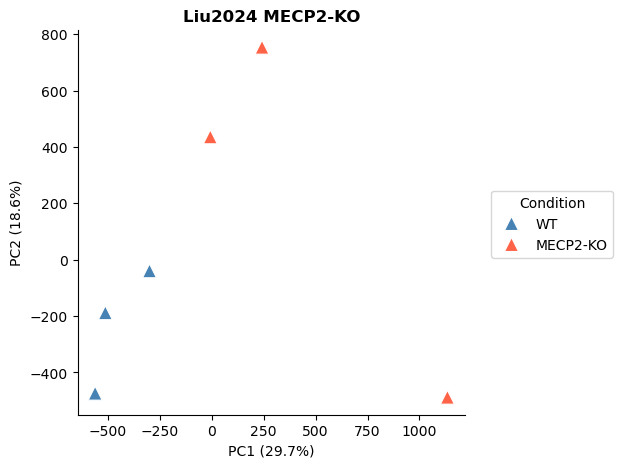

In [12]:
fig, ax = plt.subplots(figsize = (5, 5))
palette_pca = {'WT' : 'steelblue',
               'MECP2-KO' : 'tomato'}
pca_df['genotype'] = pca_df['genotype'].replace({'MECP2.KO' : 'MECP2-KO',
                                                 'MECP2.WT' : 'WT'})
sns.scatterplot(data = pca_df, x = 'PC1', y = 'PC2', palette = palette_pca, hue = 'genotype', s = 100, marker = '^')
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)") # f-string é uma forma moderna de formatar strings em python, valor da variância * 100 para meter em percentagem e dps coloca só com uma casa decimal
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Liu2024 MECP2-KO", fontweight = 'bold', fontsize = 12)
ax.legend(title = 'Condition', bbox_to_anchor = (1.4, 0.6))
sns.despine()
plt.show()


Boxplot

In [13]:
# Assemble the new table
log2cpm_df.insert(0, 'TE', TEs)
goi_df = log2cpm_df[log2cpm_df['TE'].isin(genes_of_interest)]

long_df = goi_df.melt(id_vars = 'TE', var_name = 'Sample Name', value_name = 'log2(CPM)')
long_df = long_df.merge(clinical_data, on = 'Sample Name', how = 'left')
long_df = long_df[long_df['genotype'].isin(['MECP2.KO', 'MECP2.WT']) ]

print(clinical_data.head())

# Assemble the plot

fig, ax = plt.subplots(figsize = (12, 12))

palette_boxplot = {'MECP2.KO' : 'tomato',
                   'MECP2.WT' : 'steelblue'}

sns.boxplot(data = long_df, x = 'TE', y = 'log2(CPM)', hue = 'genotype', palette = palette_boxplot,
                fliersize = 2, linewidth = 2)

ax.set_title('Boxplot - TEs - Liu MECP2.KO', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('TEs')
ax.set_ylabel('log2(CPM)')
ax.tick_params(axis = 'x', rotation = 45)



TypeError: only list-like objects are allowed to be passed to isin(), you passed a `NoneType`